# 

In [106]:
%load_ext autoreload
%autoreload 2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torchsummary import summary
from M2.DP import DPForwardSolver
from M2.Utils.source import source
from M2.PINN.model import AcousticPINN, g, PINNForwardSolver
from M2.PINN.loss import loss_fn
from M2.PINN.training import train_pinn, train_pinn2
from M2.inverse_problem import inverse_function
from M2.Utils.visualization import check_seismograms

device = "cpu" #"mps"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Utils :

In [79]:
def plot_trajectories(histories, true_epicenter, sensors, labels=None, colors=None, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5)):
    """
    histories: list of (N, 2) arrays
    true_epicenter: (ex, ey)
    sensors: (K, 2) tensor
    labels: list of strings, one per history
    colors: list of colors, one per history
    """
    if not isinstance(histories, list):
        histories = [histories]
    if labels is None:
        labels = [f"Trajectory {i}" for i in range(len(histories))]
    if colors is None:
        default = ["blue", "purple", "orange", "teal", "brown", "pink"]
        colors = default[:len(histories)]

    fig, ax = plt.subplots(figsize=(7, 7))

    for hist, label, color in zip(histories, labels, colors):
        hist = np.array(hist)
        ax.plot(hist[:, 0], hist[:, 1], color=color, linewidth=1.5, alpha=0.7, zorder=3, label=label)
        ax.scatter(hist[:-1, 0], hist[:-1, 1], color=color, s=40, edgecolors="white", linewidths=0.5, zorder=5)
        ax.scatter(hist[-1, 0], hist[-1, 1], color=color, s=60, edgecolors="white", linewidths=0.5, zorder=7)

    ax.scatter(hist[0, 0], hist[0, 1], marker=".", color="red", s=100, zorder=8, label="Initial guess")
    ax.scatter(*true_epicenter, marker="*", color="green", s=300, zorder=6, label="True epicenter")
    ax.scatter(sensors[:, 0], sensors[:, 1], marker="^", color="black", s=120, zorder=5, label="Seismometers")

    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("y", fontsize=12)
    ax.set_title("Epicenter inversion trajectory", fontsize=14)
    ax.legend(fontsize=10, loc="upper left")
    ax.set_aspect("equal")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Experiments :

In [82]:
sensors = torch.tensor([[-1.0, 0.0],
                        [ 1.0, 0.0]], device="cpu")
true_ex, true_ey = 0.0, 0.0

x_min, x_max, y_min, y_max = -5, 5, -5, 5
nx, ny = 200, 200
t, nt = 5, 750

### C constant : 

In [ ]:
dp_solver = DPForwardSolver2(
    sensors=sensors,
    c=5.0,
    x_min=x_min, x_max=x_max,
    y_min=y_min, y_max=y_max,
    Nx=nx, Ny=ny,
    Nt=nt, T=t,
    A=100.0,                        # amplitude_g in the notebook
    t0=1.0,                         # Ricker peak time
    f0=1.0,                         # Ricker frequency
    gamma=1.0 / (2.0 * 0.3**2),    # converts sigma=0.3 to your gamma
    device="cpu",
)

seismograms = dp_solver.forward(e_x=true_ex, e_y=true_ey)  # (750, 3)

t_fd = np.linspace(0, t, nt)
fd_seis = {
    '(-1,0)': seismograms[:, 0].detach().cpu().numpy(),
    '(1,0)':  seismograms[:, 1].detach().cpu().numpy(),
}
traces_obs = dp_solver.forward(e_x=true_ex, e_y=true_ey).detach()

In [ ]:
e_hat_dp, traces_dp, _, history_dp = inverse_function(
    forward=dp_solver,
    traces_obs=traces_obs,
    dt=dp_solver.dt,
    init=(1, 1),
    steps=10,
    lr=1,
    max_iter=3,
    device="cpu",
)
history_dp.insert(0, (1, 1))  # add initial guess to history
history_dp = np.array(history_dp)

  0%|          | 0/10 [00:00<?, ?it/s]

In [66]:
model = AcousticPINN(n_layers=3, layer_width=64).to(device)
summary(model.cpu(), [(1, 1), (1, 1), (1, 1), (1, 1), (1, 1)])
model = model.to(device)

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 1, 64]               --
|    └─Linear: 2-1                       [-1, 1, 64]               384
|    └─Tanh: 2-2                         [-1, 1, 64]               --
├─ModuleList: 1                          []                        --
|    └─Sequential: 2-3                   [-1, 1, 64]               --
|    |    └─Linear: 3-1                  [-1, 1, 64]               4,160
|    |    └─Tanh: 3-2                    [-1, 1, 64]               --
|    └─Sequential: 2-4                   [-1, 1, 64]               --
|    |    └─Linear: 3-3                  [-1, 1, 64]               4,160
|    |    └─Tanh: 3-4                    [-1, 1, 64]               --
|    └─Sequential: 2-5                   [-1, 1, 64]               --
|    |    └─Linear: 3-5                  [-1, 1, 64]               4,160
|    |    └─Tanh: 3-6                    [-1, 1, 64]               --
├─Mod

In [67]:
# model = train_pinn(model, fd_seis, t_fd, device=device)
# torch.save(model,"model.pt")
model = torch.load(
    "model_cpu.pt",
    map_location=torch.device("cpu"),
    weights_only=False
)
model.eval()

AcousticPINN(
  (lift): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): Tanh()
  )
  (layers1): ModuleList(
    (0-2): 3 x Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): Tanh()
    )
  )
  (layers2): ModuleList(
    (0-2): 3 x Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): Tanh()
    )
  )
  (compress): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Tanh()
  )
  (output): Sequential(
    (0): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
pinn_solver = PINNForwardSolver(
    model=model,
    sensors=sensors,
    t_max=t, n_t=nt,
    x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max,
    device=device,
)

e_hat_pinn, traces_pinn, _, history_pinn = inverse_function(
    forward=pinn_solver,
    traces_obs=pinn_solver.forward(e_x=true_ex, e_y=true_ey).detach(),
    dt=pinn_solver.dt,
    init=(1.0, 1.0),
    steps=50,
    lr=1,
    max_iter=1,
    device=device,
)
history_pinn.insert(0, (1.0, 1.0))  # add initial guess to history
history_pinn = np.array(history_pinn)

  0%|          | 0/50 [00:00<?, ?it/s]

In [97]:
pinn_solver2 = PINNForwardSolver(
    model=model,
    sensors=sensors,
    t_max=t, n_t=nt,
    x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max,
    device=device,
)

e_hat_pinn2, traces_pinn2, _, history_pinn2 = inverse_function(
    forward=pinn_solver2,
    traces_obs=traces_obs,  # use the true seismograms as observations
    dt=pinn_solver2.dt,
    init=(1.0, 1.0),
    steps=50,
    lr=1,
    max_iter=1,
    device=device,
)
history_pinn2.insert(0, (1.0, 1.0))  # add initial guess to history
history_pinn2 = np.array(history_pinn2)

  0%|          | 0/50 [00:00<?, ?it/s]

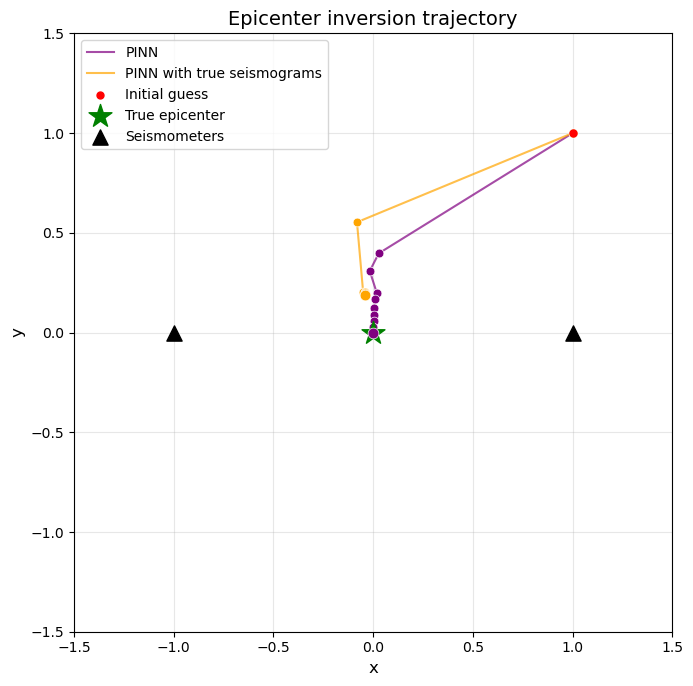

In [98]:
plot_trajectories(
    [history_pinn, history_pinn2],
    (true_ex, true_ey),
    sensors.cpu(),
    labels=["PINN", "PINN with true seismograms"],
    colors=["purple", "orange"],
)

## C field : 

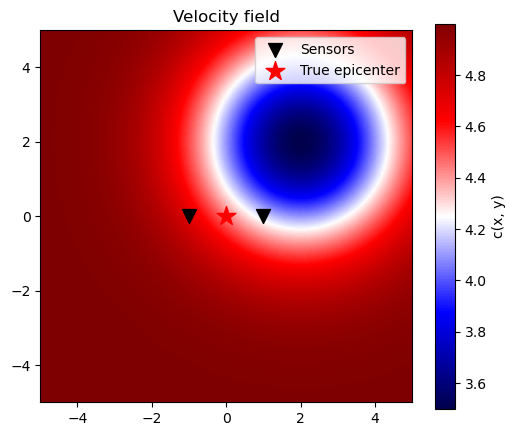

In [93]:
x = torch.linspace(x_min, x_max, nx)
y = torch.linspace(y_min, y_max, ny)
X, Y = torch.meshgrid(x, y, indexing="xy")
X, Y = X.T.contiguous(), Y.T.contiguous()

c_field = 5.0 - 1.5 * torch.exp(-((X - 2)**2 + (Y - 2)**2) / (2 * 2**2))
plt.figure(figsize=(6, 5))
plt.imshow(c_field.numpy(), extent=[x_min, x_max, y_min, y_max], origin="lower", cmap="seismic")
plt.colorbar(label="c(x, y)")
plt.scatter(*sensors.T, color="black", marker="v", s=100, zorder=5, label="Sensors")
plt.scatter(true_ex, true_ey, color="red", marker="*", s=200, zorder=5, label="True epicenter")
plt.legend()
plt.title("Velocity field")
plt.show()

In [ ]:
dp_hetero = DPForwardSolver2(
    sensors=sensors,
    c=c_field,
    x_min=x_min, x_max=x_max,
    y_min=y_min, y_max=y_max,
    Nx=Nx, Ny=Ny,
    Nt=nt, T=t,
    A=100.0, t0=1.0, f0=1.0,
    gamma=1.0 / (2.0 * 0.3**2),
    device="cpu",
)

traces_obs_hetero = dp_hetero.forward(e_x=true_ex, e_y=true_ey).detach()

e_hat_hetero, traces_pred_hetero, _, history_hetero = inverse_function(
    forward=dp_hetero,
    traces_obs=traces_obs_hetero,
    dt=dp_hetero.dt,
    init=(1.0, 1.0),
    steps=10,
    lr=1,
    max_iter=3,
    device="cpu",
)
history_hetero.insert(0, (1.0, 1.0))
history_hetero = np.array(history_hetero)

print(f"True: ({true_ex}, {true_ey})")
print(f"Recovered: ({e_hat_hetero[0].item():.4f}, {e_hat_hetero[1].item():.4f})")
print(f"Error: {torch.norm(e_hat_hetero - torch.tensor([true_ex, true_ey])).item():.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

True: (0.0, 0.0)
Recovered: (-0.0000, -0.0000)
Error: 0.0000


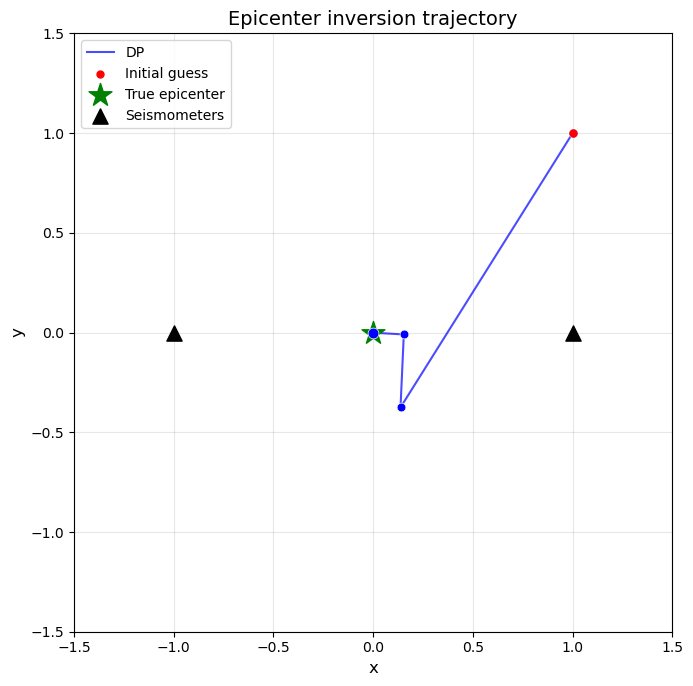

In [ ]:
plot_trajectories(history_hetero, (true_ex, true_ey), sensors.cpu(), labels=["DP"])

In [ ]:
# observations from the TRUE (heterogeneous) medium
traces_obs_hetero = dp_hetero.forward(e_x=true_ex, e_y=true_ey).detach()

# invert with the WRONG model (homogeneous c=5)
e_hat_wrong, _, _, history_wrong = inverse_function(
    forward=dp_solver,          # uses c=5 everywhere
    traces_obs=traces_obs_hetero,
    dt=dp_solver.dt,
    init=(1.0, 1.0),
    steps=10,
    lr=1,
    max_iter=3,
    device="cpu",
)


history_wrong.insert(0, (1.0, 1.0))
history_wrong = np.array(history_wrong)

print(f"True: ({true_ex}, {true_ey})")
print(f"Recovered: ({e_hat_wrong[0].item():.4f}, {e_hat_wrong[1].item():.4f})")
print(f"Error: {torch.norm(e_hat_wrong - torch.tensor([true_ex, true_ey])).item():.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]

True: (0.0, 0.0)
Recovered: (0.7591, 0.0849)
Error: 0.7639


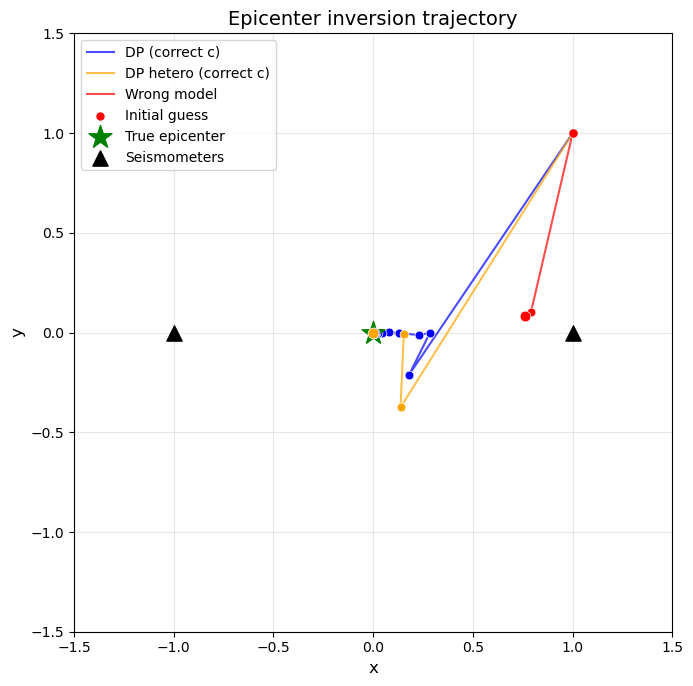

In [78]:
plot_trajectories(
    [history_dp, history_hetero, history_wrong],
    (true_ex, true_ey),
    sensors.cpu(),
    labels=["DP (correct c)", "DP hetero (correct c)", "Wrong model"],
    colors=["blue", "orange", "red"],
)

## Other : 

In [107]:
seismograms = dp_hetero.forward(e_x=true_ex, e_y=true_ey)  # (750, 2)

t_fd = np.linspace(0, t, nt)
fd_seis = {
    '(-1,0)': seismograms[:, 0].detach().cpu().numpy(),
    '(1,0)':  seismograms[:, 1].detach().cpu().numpy(),
}

  0%|          | 0/10001 [00:00<?, ?it/s]

Iteration 0


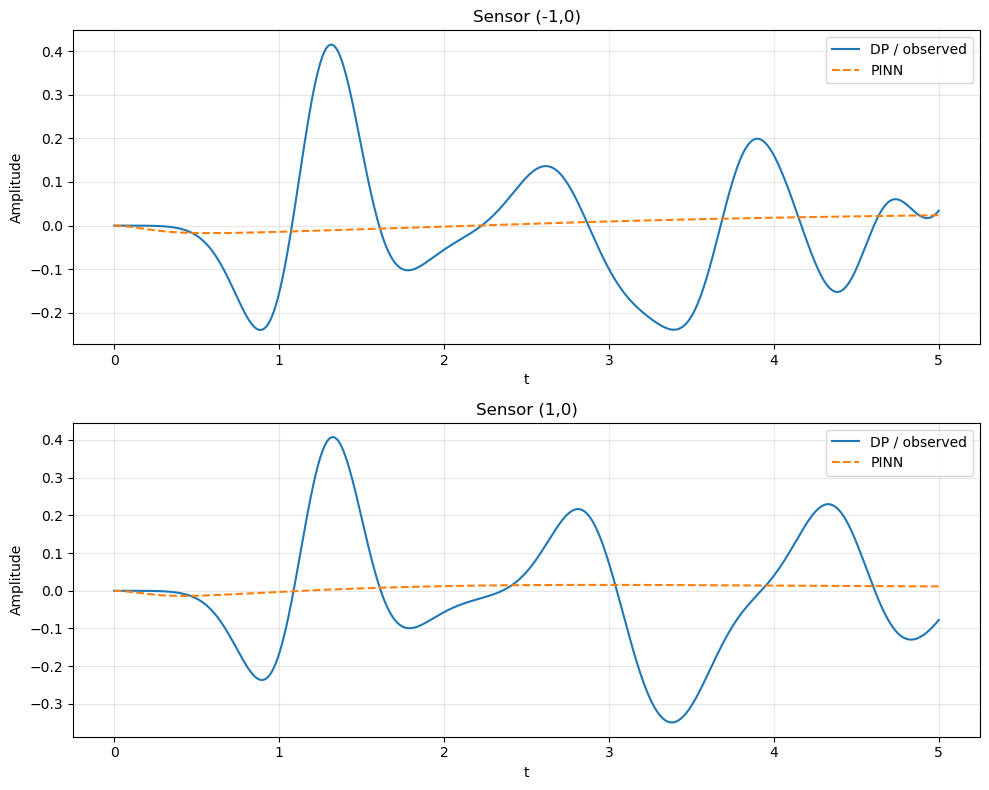

Iteration 500


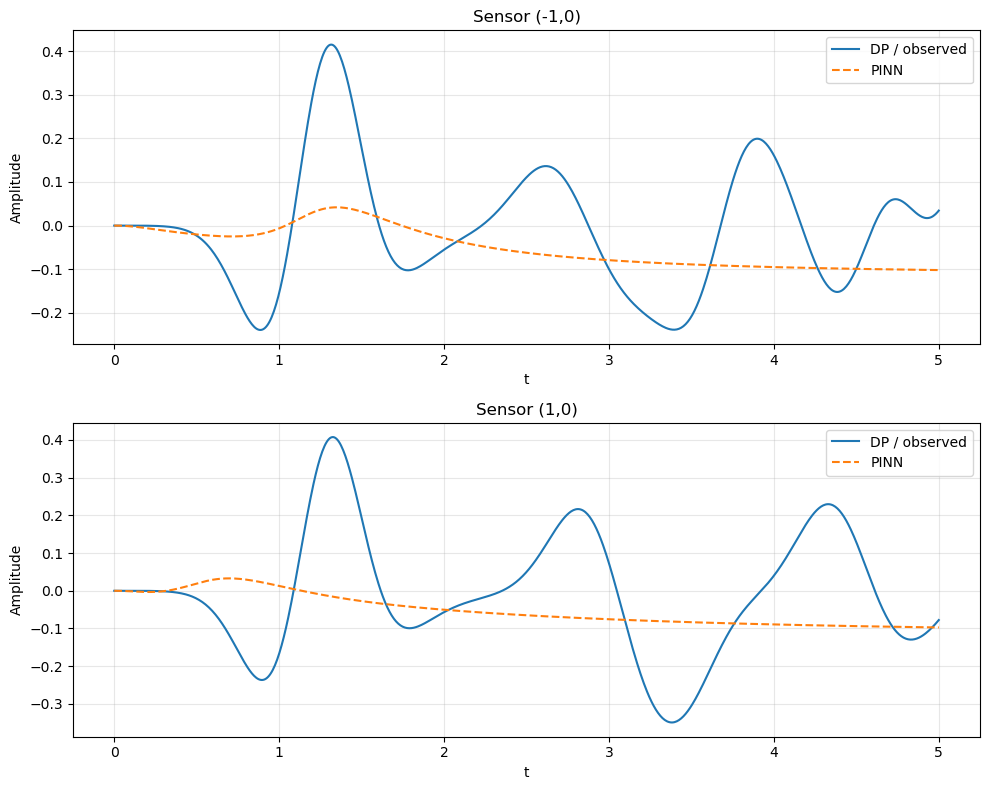

Iteration 1000


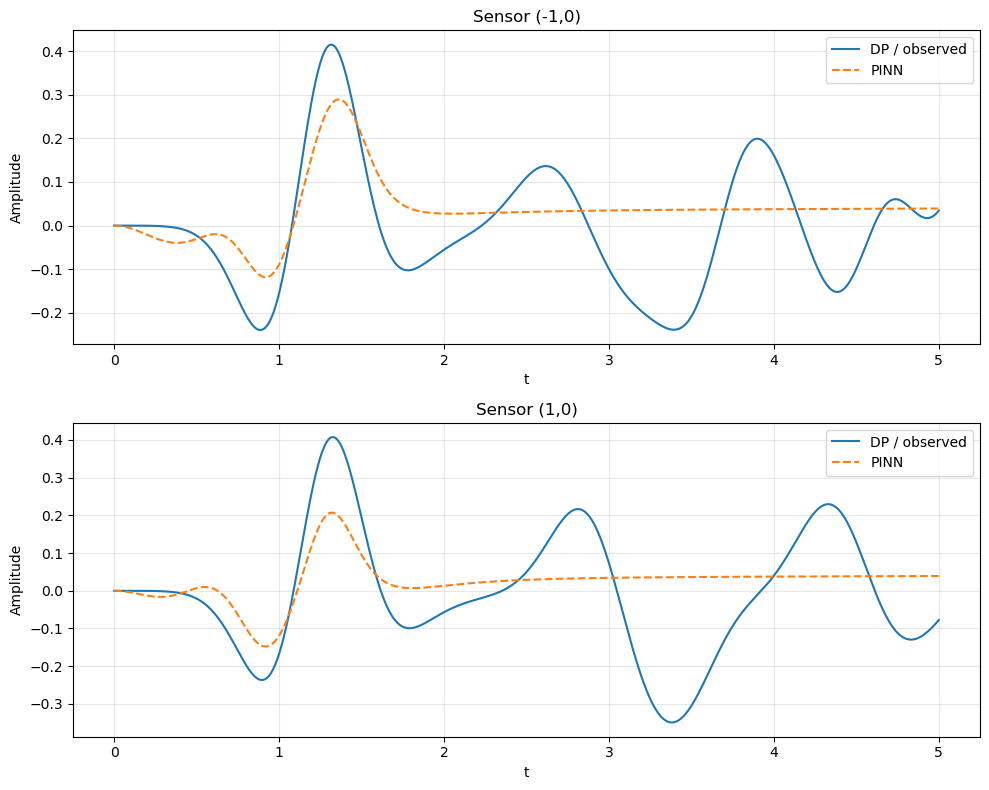

Iteration 1500


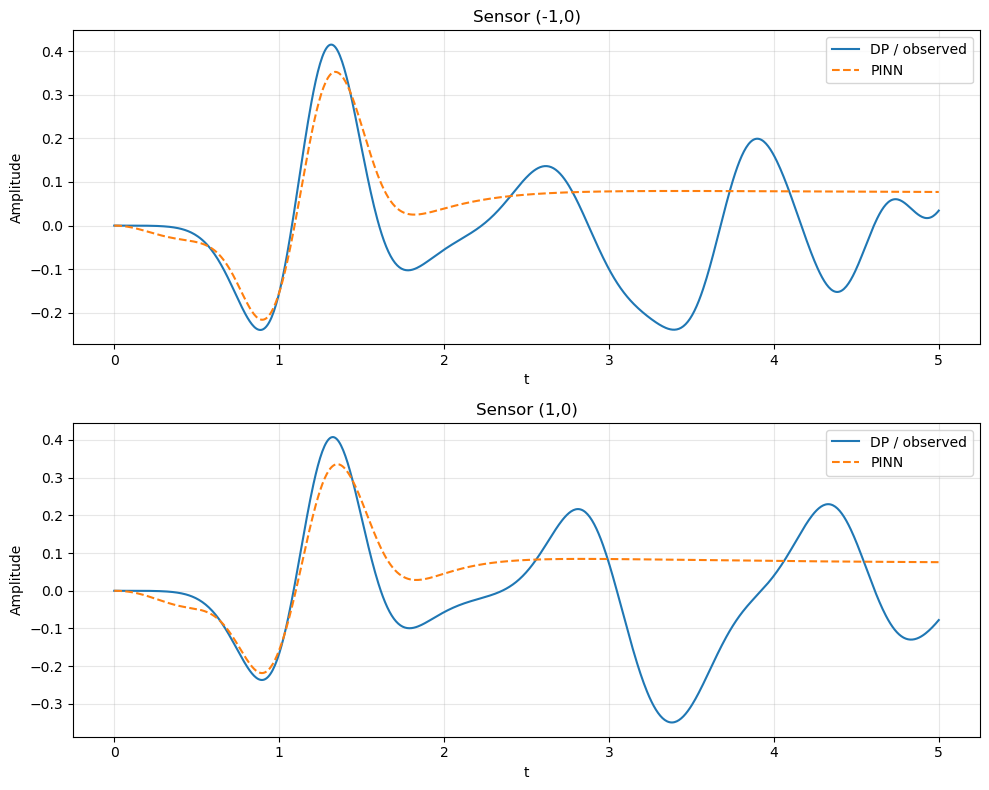

Iteration 2000


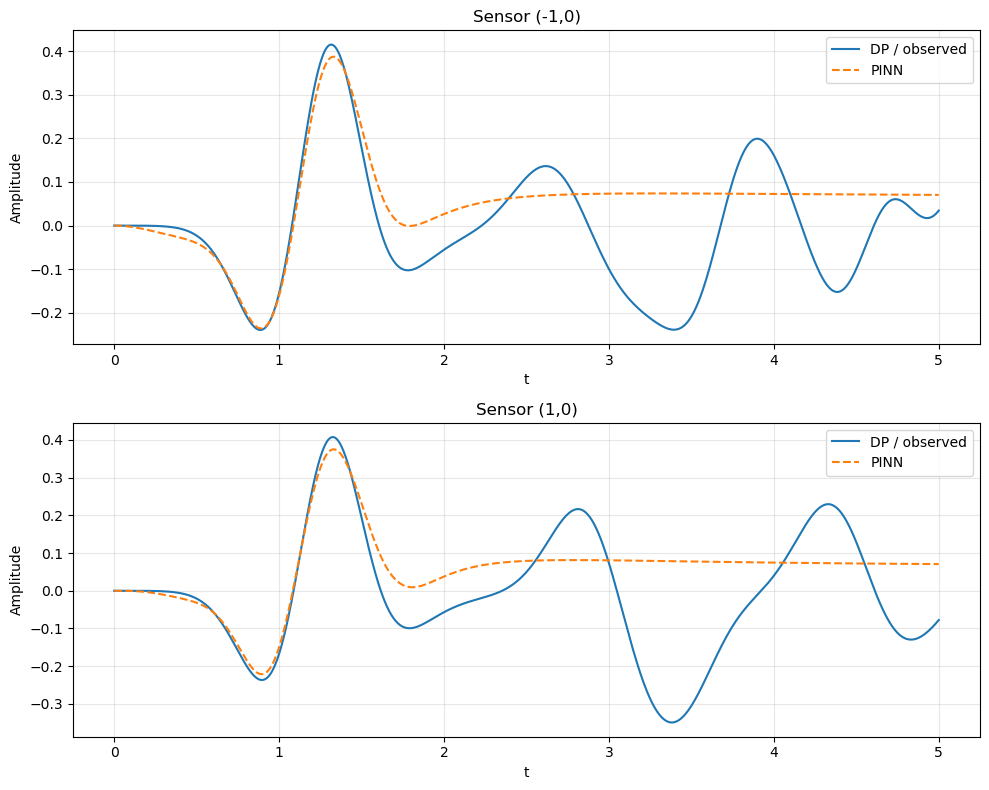

Iteration 2500


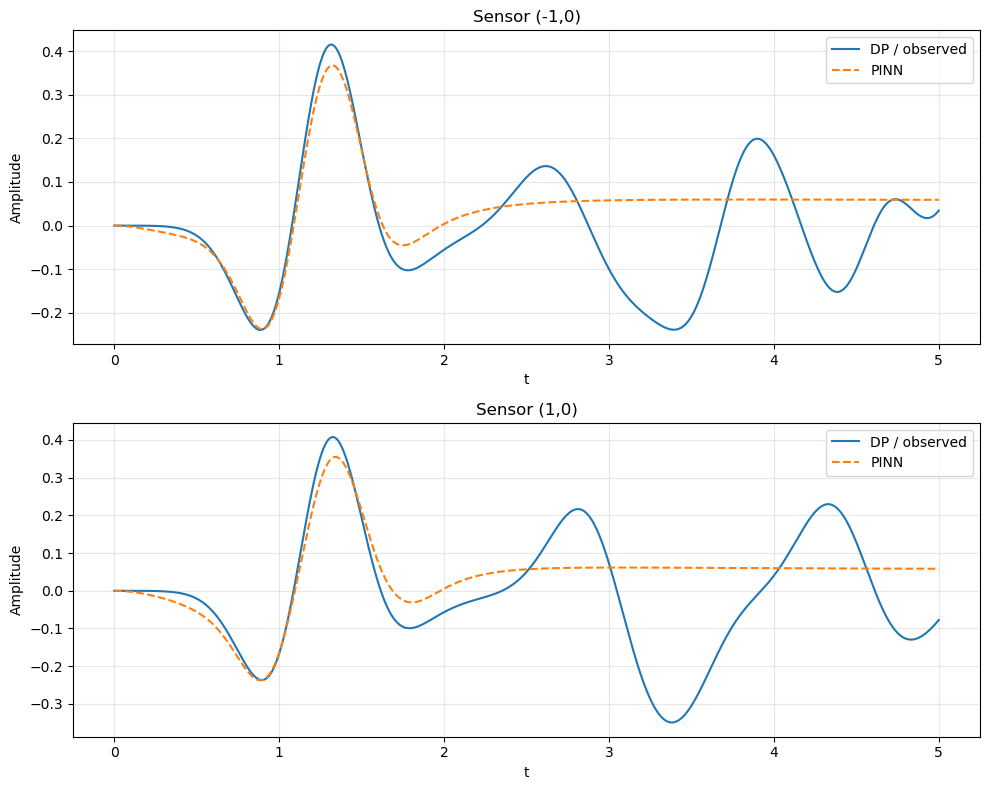

Iteration 3000


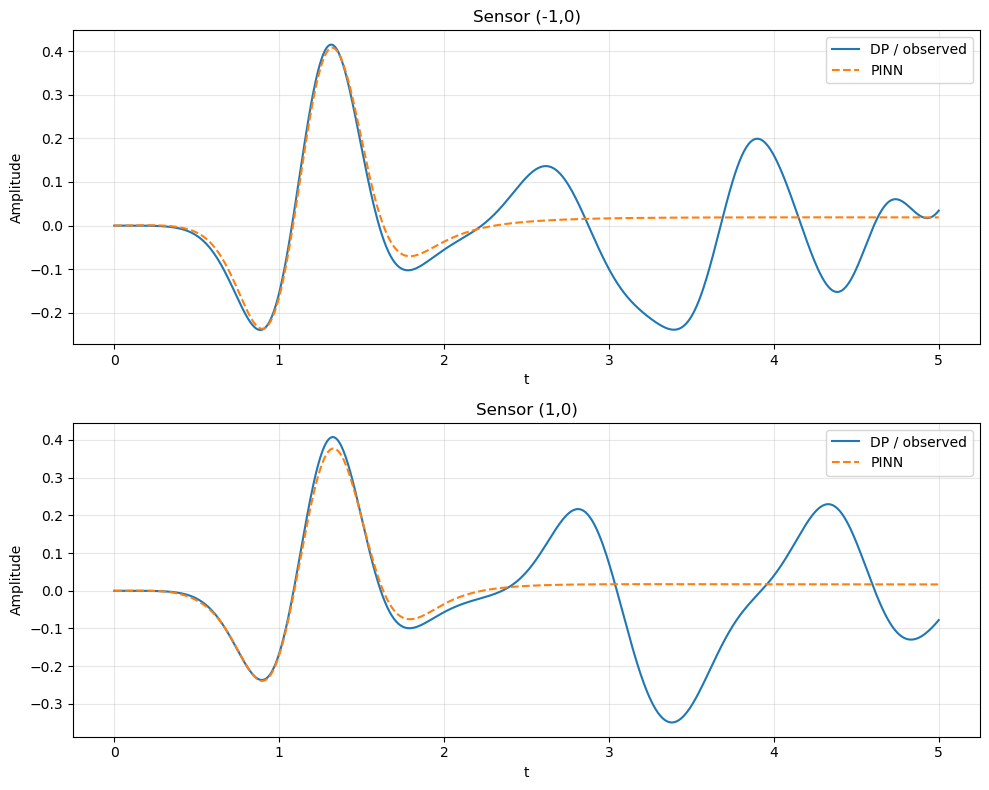

Iteration 3500


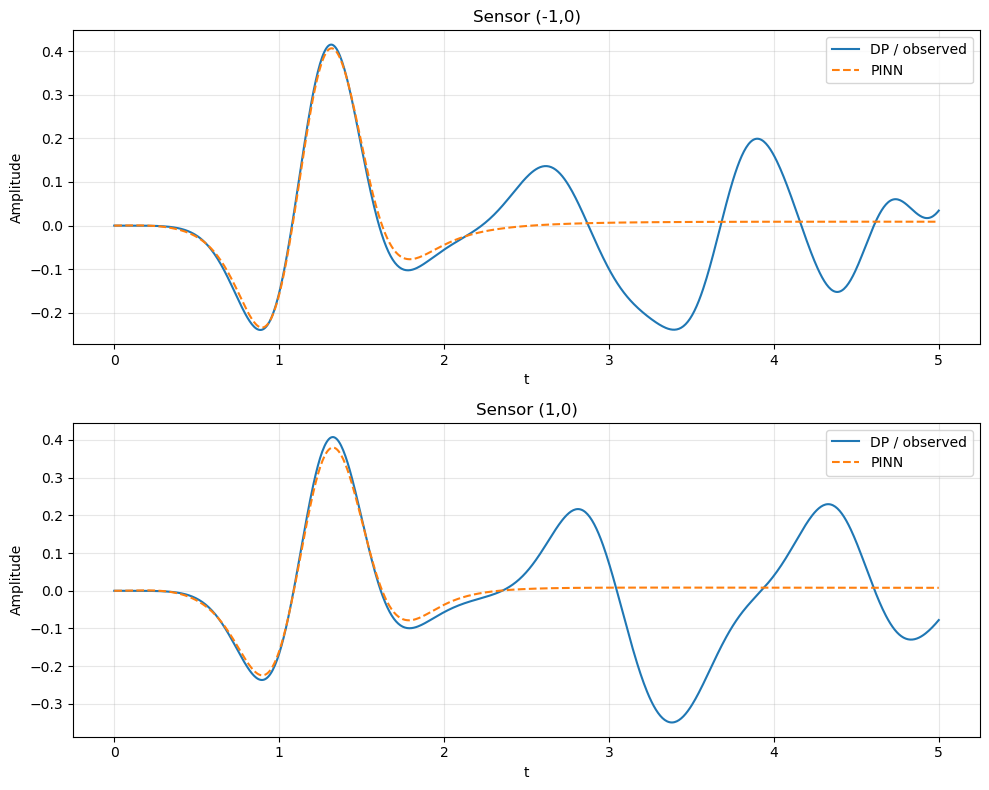

Iteration 4000


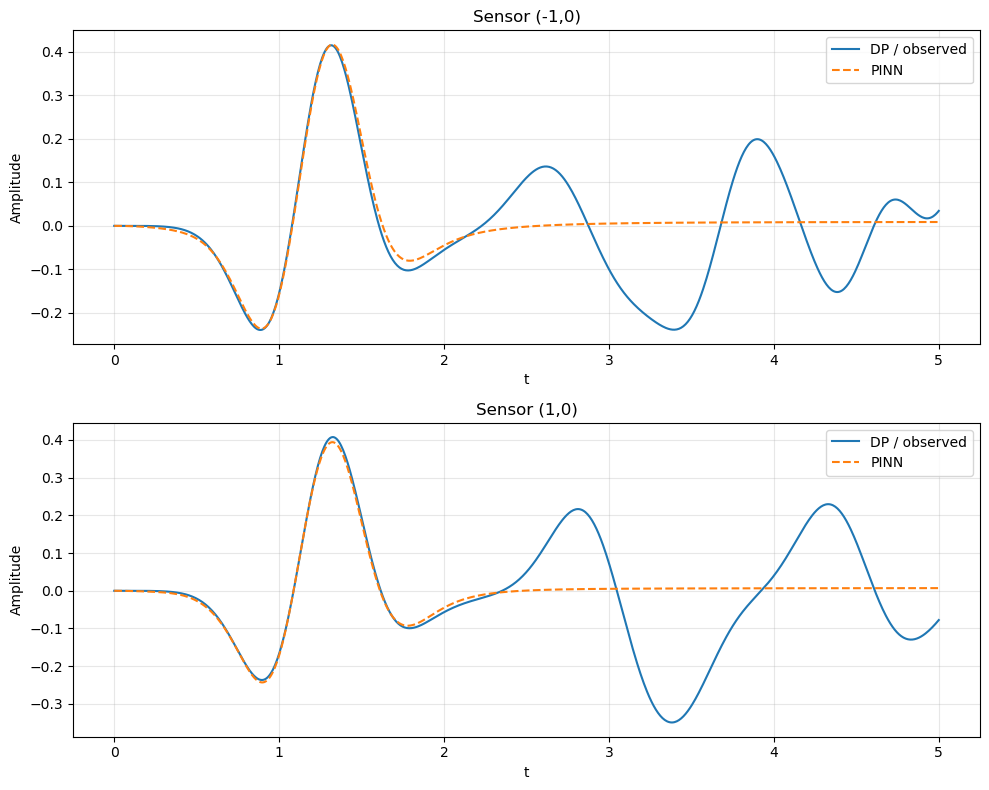

Iteration 4500


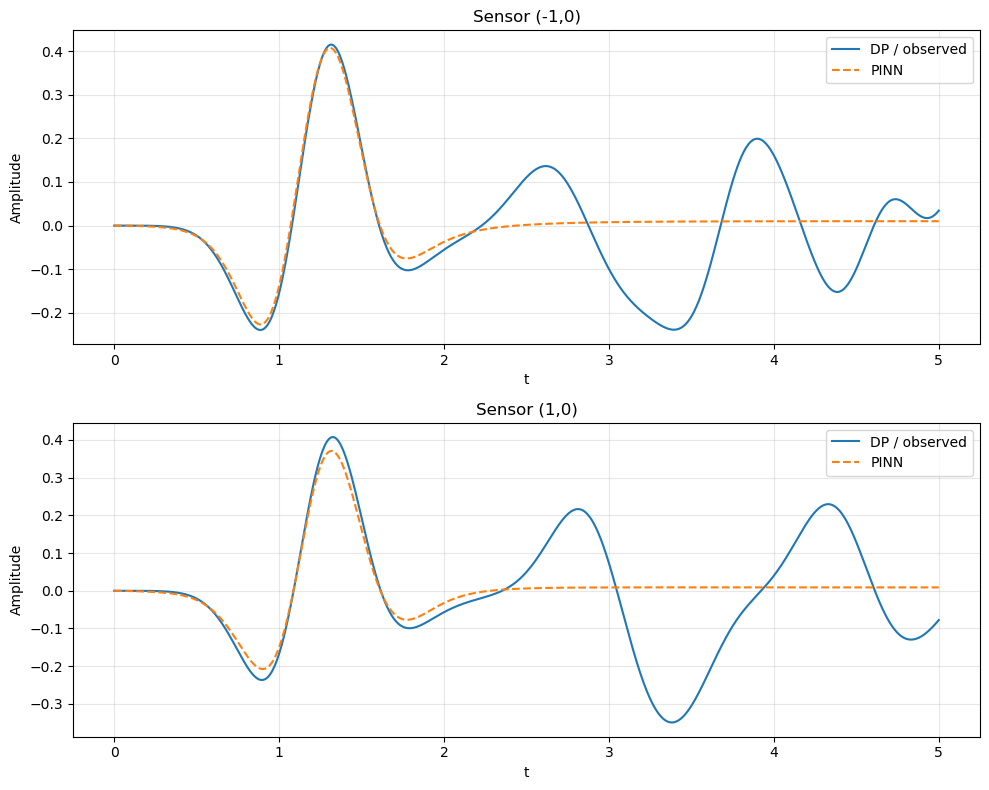

Iteration 5000


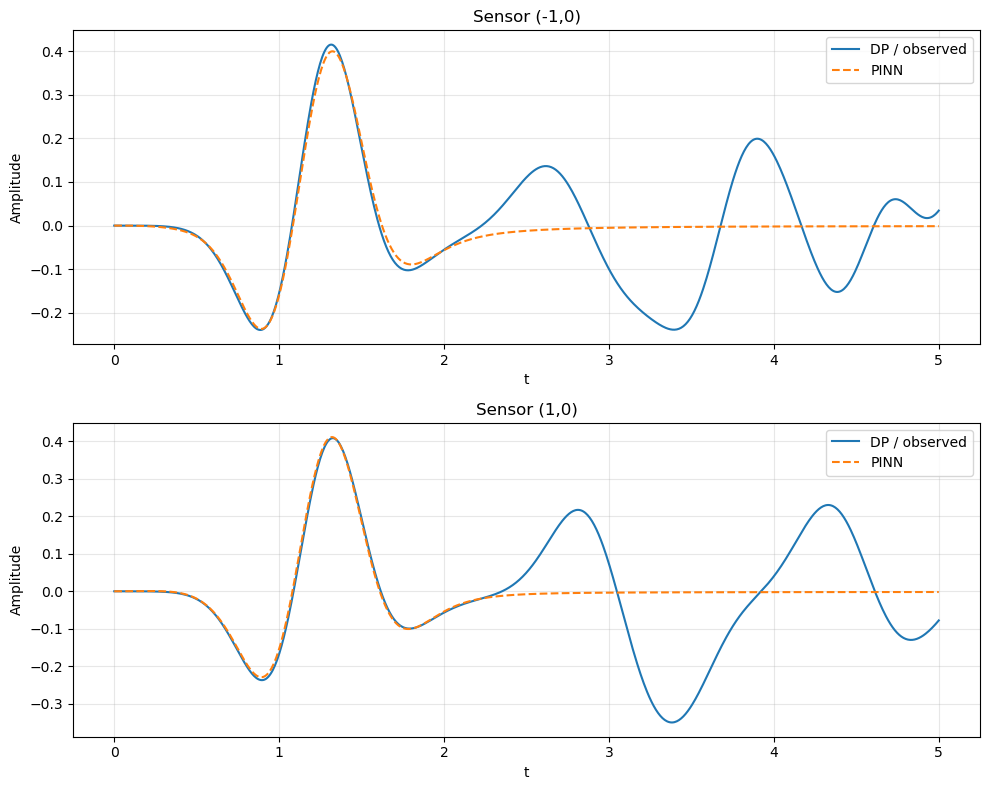

Iteration 5500


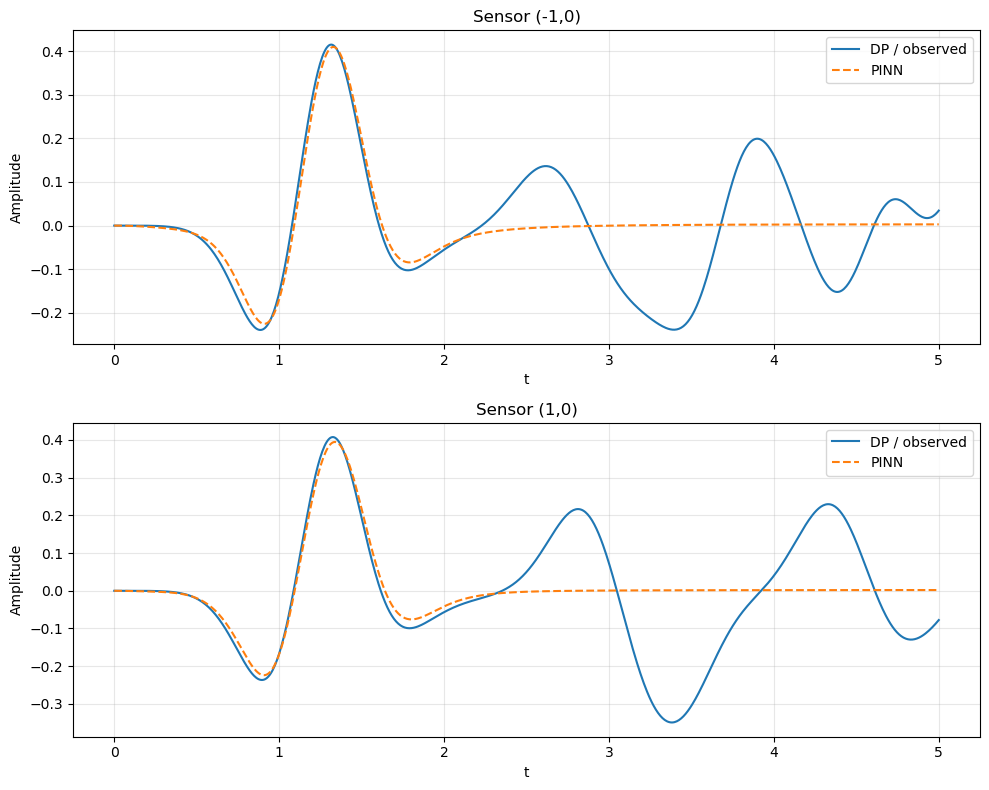

Iteration 6000


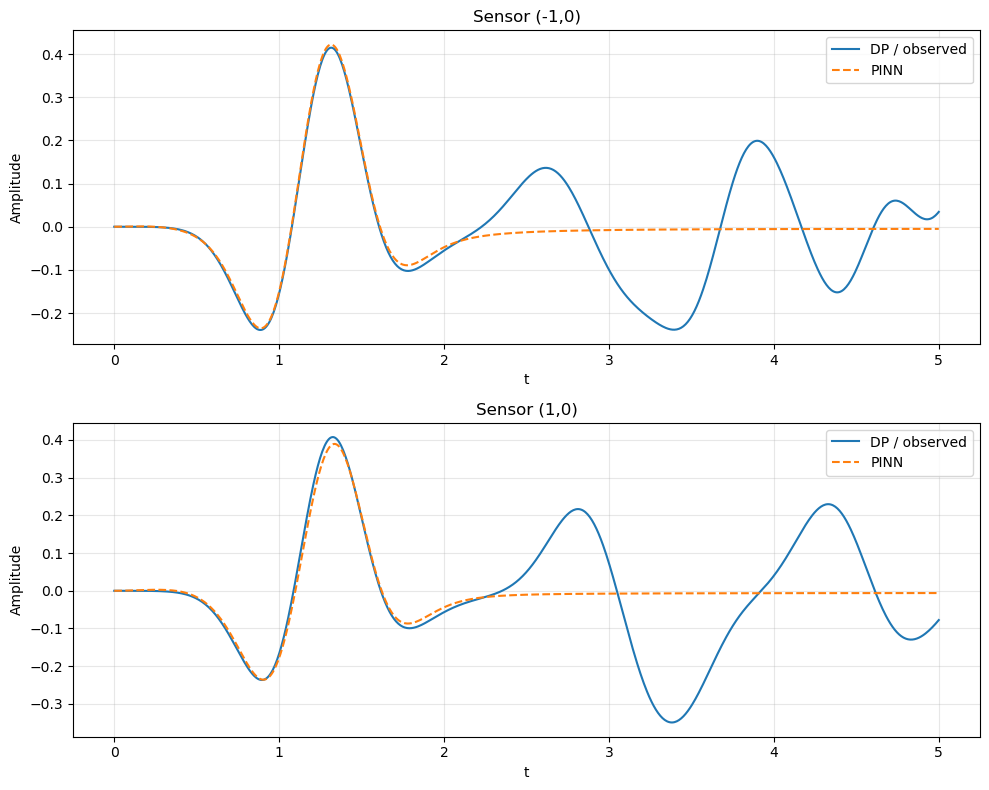

Iteration 6500


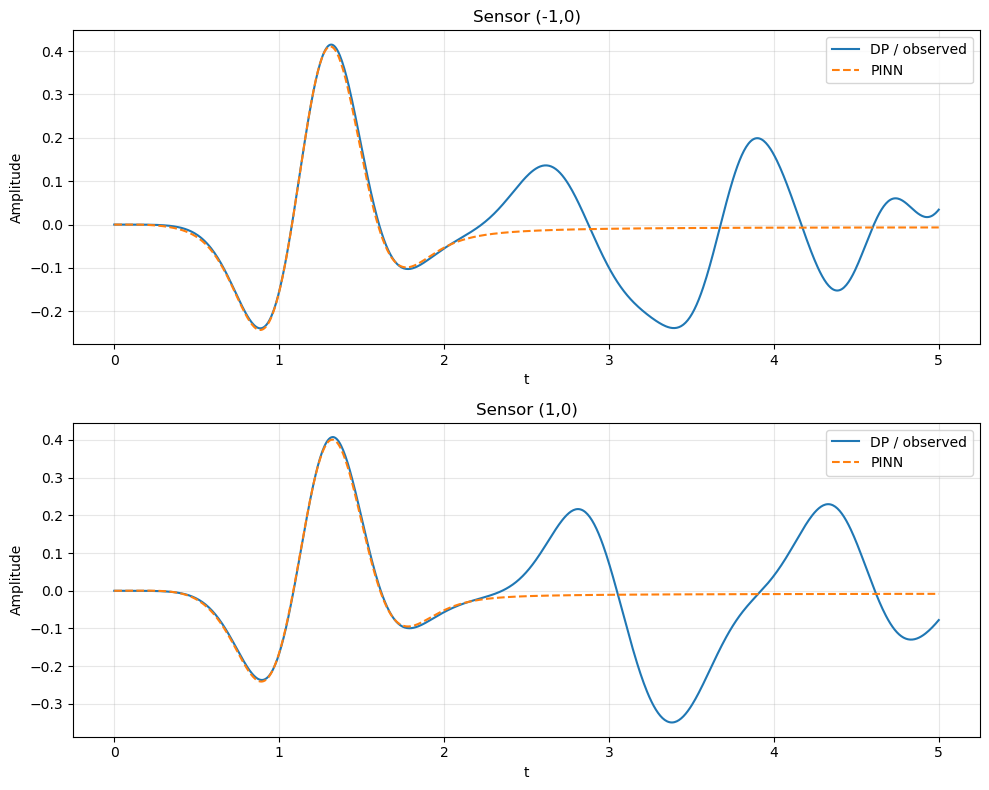

Iteration 7000


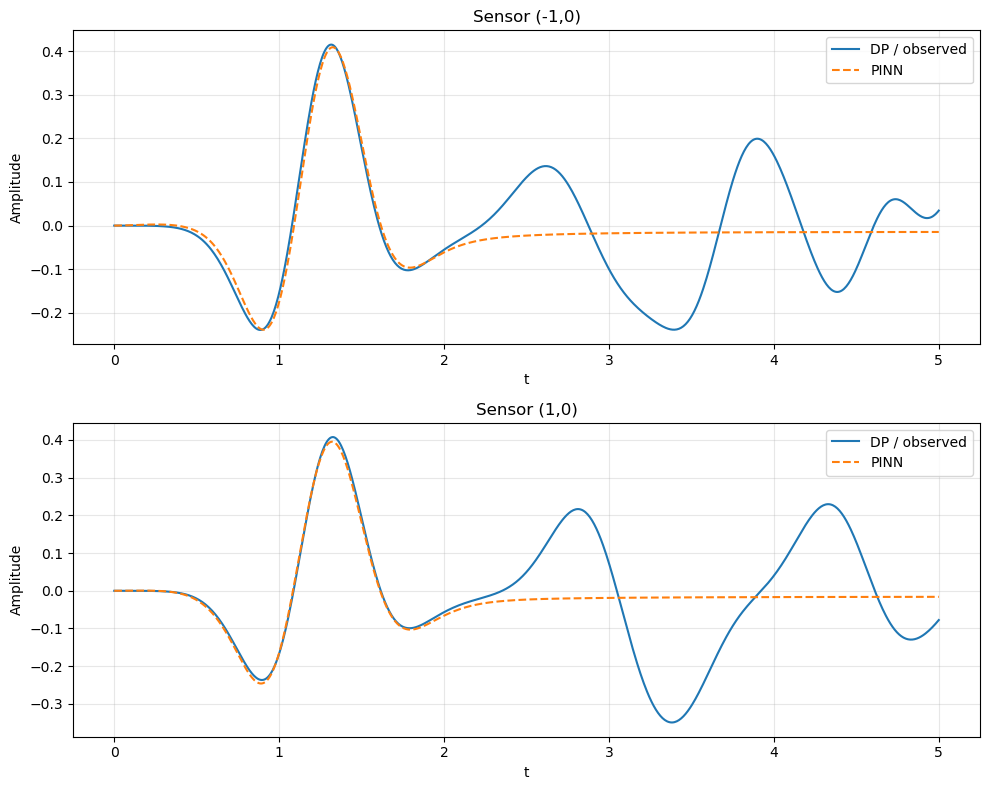

Iteration 7500


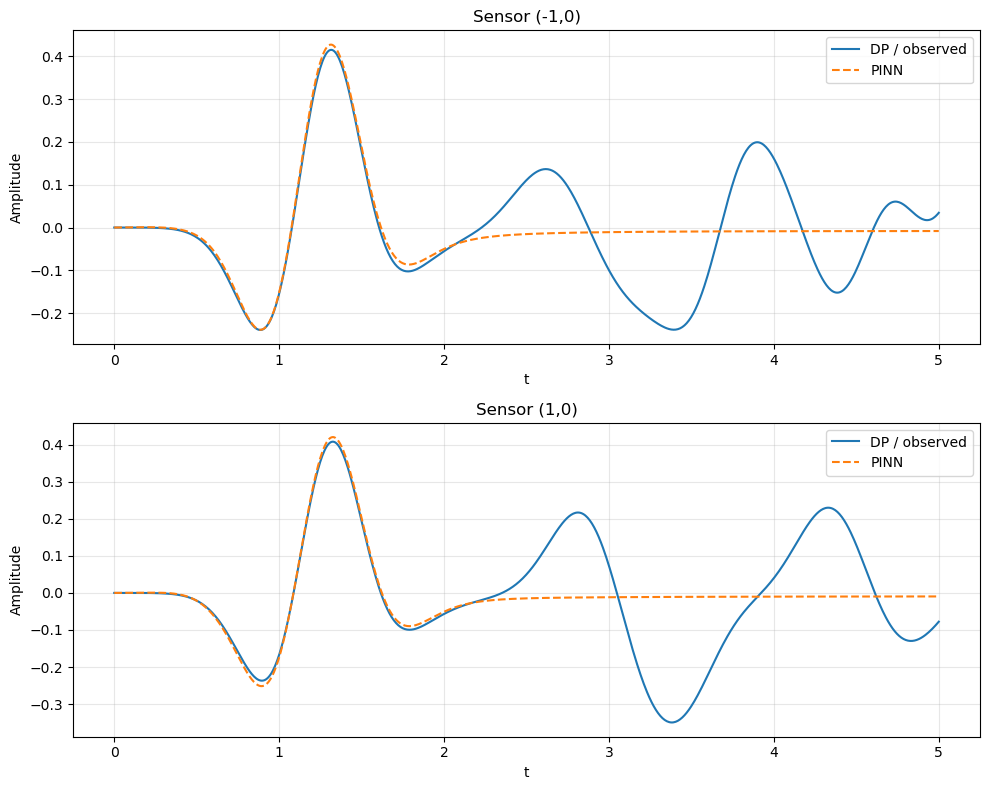

Iteration 8000


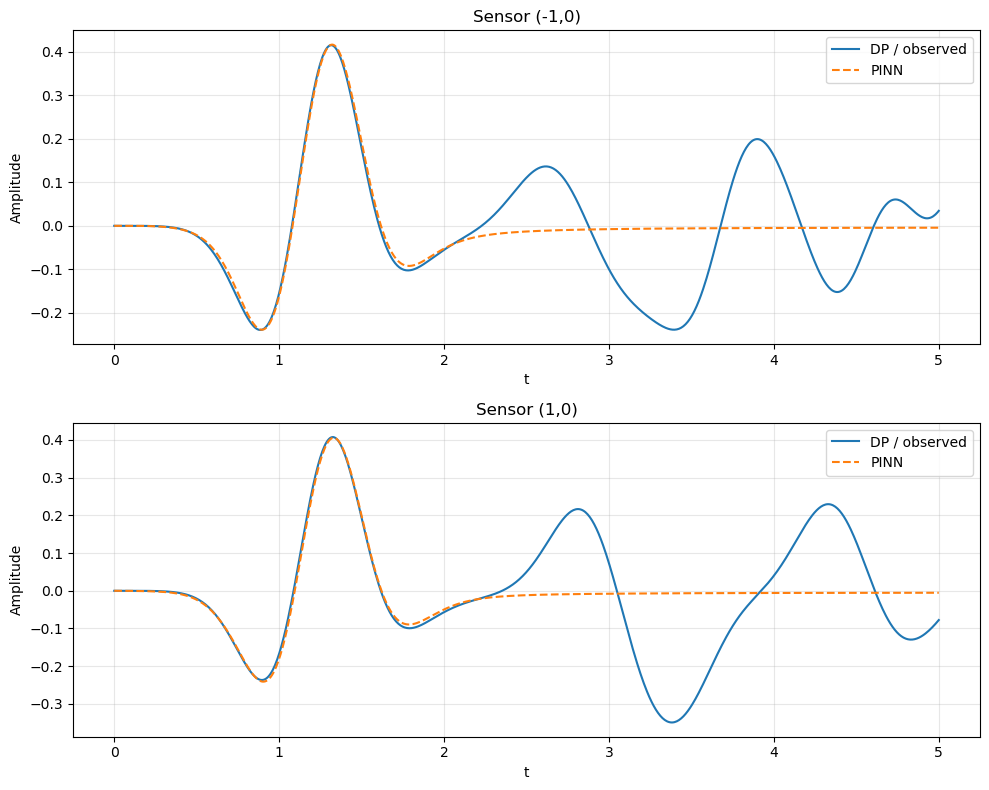

Iteration 8500


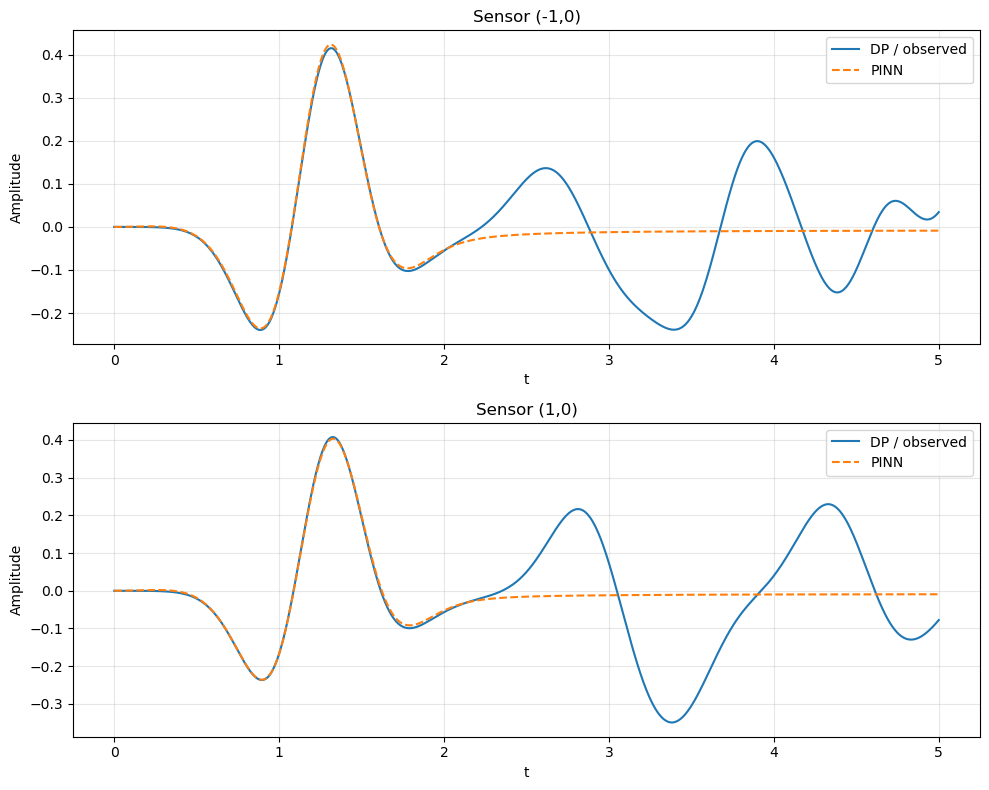

Iteration 9000


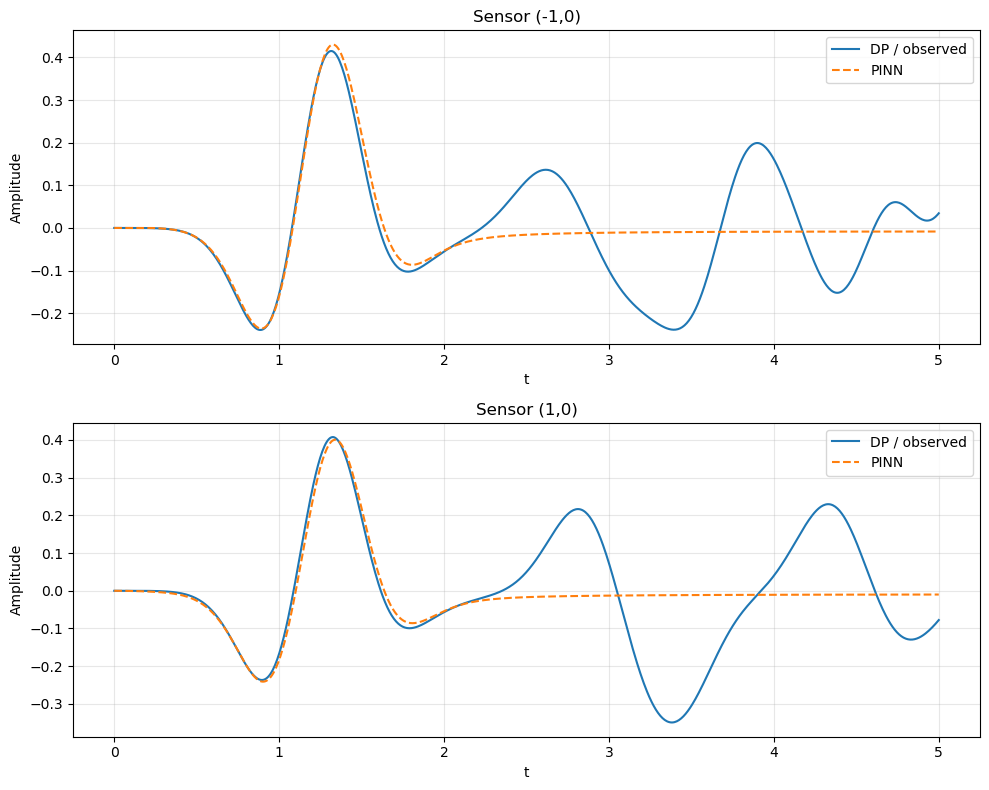

Iteration 9500


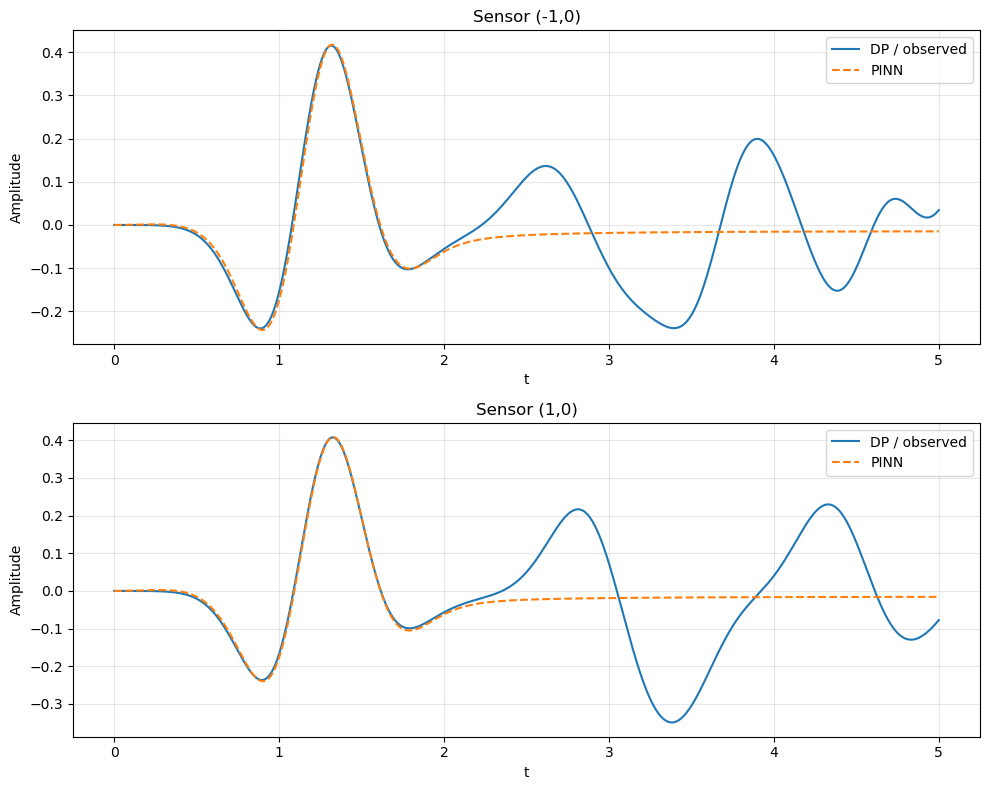

Iteration 10000


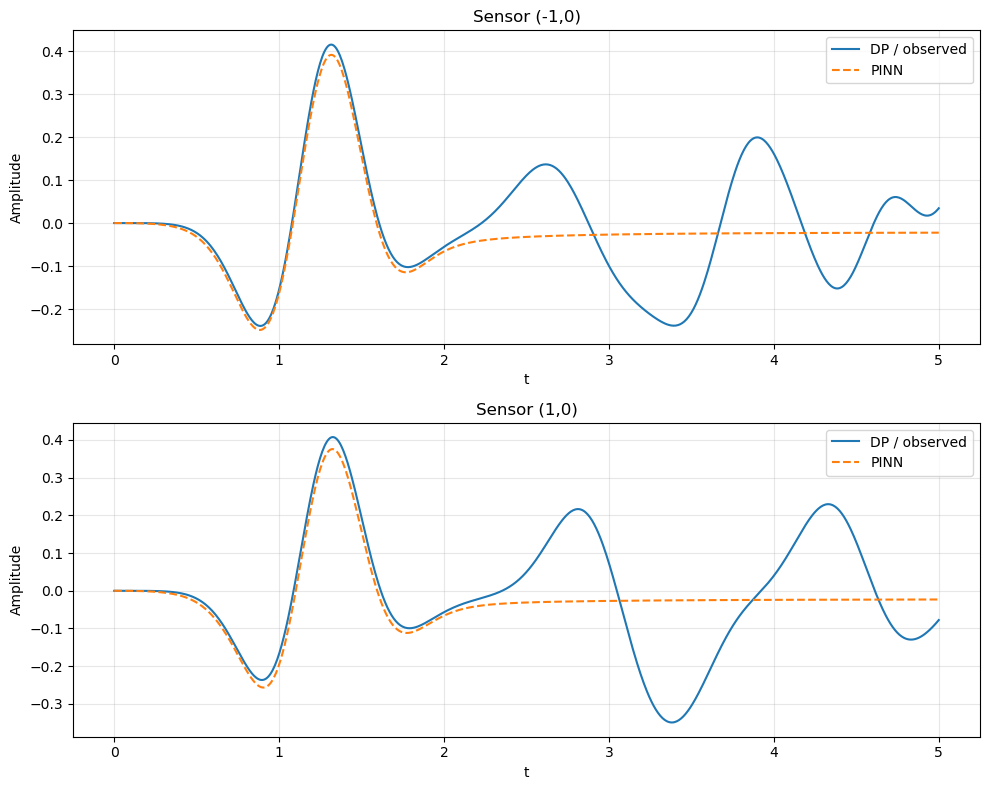

In [108]:
pinn_model = AcousticPINN(n_layers=3, layer_width=64).to(device)
# summary(pinn_model.cpu(), [(1, 1), (1, 1), (1, 1), (1, 1), (1, 1)])
pinn_model = pinn_model.to(device)

pinn_model = train_pinn2(
    pinn_model,
    fd_seis,
    t_fd,
    sensors=sensors,
    e_x=true_ex,
    e_y=true_ey,
    c=c_field,
    x_min=-5, x_max=5,
    y_min=-5, y_max=5,
    t_range=(0, t),
    device=device,
)


  0%|          | 0/50 [00:00<?, ?it/s]

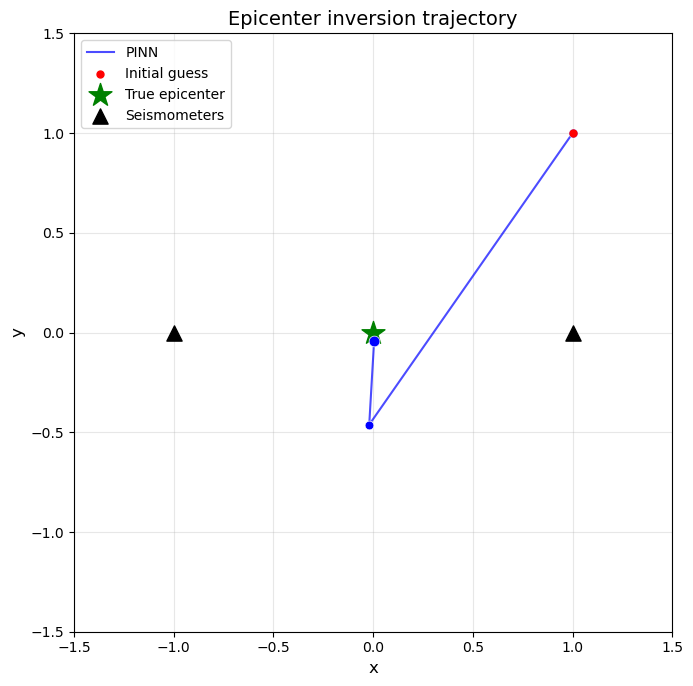

True: (0.0, 0.0)
Recovered: (0.0045, -0.0403)
Error: 0.0405


In [117]:
pinn_solver3 = PINNForwardSolver(
    model=pinn_model,
    sensors=sensors,
    t_max=t, n_t=nt,
    x_min=x_min, x_max=x_max, y_min=y_min, y_max=y_max,
    device=device,
)

e_hat_pinn3, traces_pinn3, _, history_pinn3 = inverse_function(
    forward=pinn_solver3,
    traces_obs=traces_obs_hetero,#pinn_solver3.forward(e_x=true_ex, e_y=true_ey).detach(),
    dt=pinn_solver3.dt,
    init=(1.0, 1.0),
    steps=50,
    lr=1,
    max_iter=10,
    device=device,
)
history_pinn3.insert(0, (1.0, 1.0))  # add initial guess to history
history_pinn3 = np.array(history_pinn3)

plot_trajectories(
    [history_pinn3],
    (true_ex, true_ey),
    sensors.cpu(),
    labels=["PINN"],
    colors=["blue"],
)


print(f"True: ({true_ex}, {true_ey})")
print(f"Recovered: ({e_hat_pinn3[0].item():.4f}, {e_hat_pinn3[1].item():.4f})")
print(f"Error: {torch.norm(e_hat_pinn3 - torch.tensor([true_ex, true_ey])).item():.4f}")